# Vehicle Log Sources Survey

In [ ]:
# Packages
import numpy as np
import pandas as pd
import seaborn as sns
import json
import warnings
import requests
from datetime import datetime
import os
import re
from IPython.display import HTML, display, clear_output
from ipywidgets import *
import tabulate
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap


# Disable warnings
warnings.filterwarnings("ignore")
warnings.simplefilter("ignore")

In [ ]:
#os.getcwd()
#dataset = pd.read_csv("data_vehiclelogsources.csv", sep=";", encoding='utf-8')
dataset = pd.read_excel("data_vehiclelogsources.xlsx")

In [ ]:
dataset.head()

,CASE,SERIAL,REF,QUESTNNR,MODE,STARTED,I003,I004,I005,P001,...,MAILSENT,LASTDATA,STATUS,FINISHED,Q_VIEWER,LASTPAGE,MAXPAGE,MISSING,MISSREL,TIME_RSI
0,181,NaN,NaN,base,interview,2026-05-02 22:14:57,1,1,1,2,...,NaN,2026-05-02 22:43:00,complete,1,0,8,8,43,1,1.69
1,199,NaN,NaN,base,interview,2026-05-05 18:47:16,1,1,1,3,...,NaN,2026-05-06 08:28:17,complete,1,0,8,8,43,1,1.65
2,205,NaN,NaN,base,interview,2026-05-08 14:54:57,1,1,1,2,...,NaN,2026-05-09 18:11:36,complete,1,0,8,8,49,4,0.80
3,206,NaN,NaN,base,interview,2026-05-08 16:59:59,1,1,1,3,...,NaN,2026-05-08 17:15:22,complete,1,0,8,8,46,1,0.82
4,210,NaN,NaN,base,interview,2026-05-23 01:50:11,1,1,1,3,...,NaN,2026-05-23 02:28:43,complete,1,0,8,8,42,1,1.90


In [ ]:
# Valid surveys
len(dataset)

5

## Demographics

### Survey Participant Age

In [ ]:
age = dataset["P001"].value_counts()
age

,count
P001,
3,3
2,2


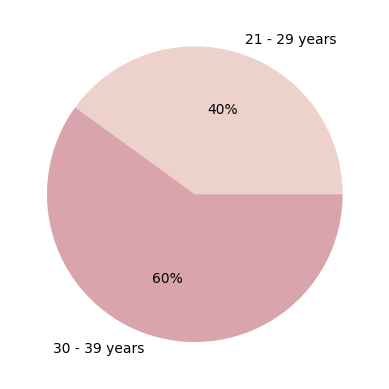

In [ ]:
colors = sns.cubehelix_palette(6)
y = np.array([0, 2, 3, 0, 0, 0])
mylabels = ["20 years and under", "21 - 29 years", "30 - 39 years", "40 - 49 years", "50 - 59 years", "60  years and above"]

# Keep only non-zero values in the graph
mask = y>0

y_filtered = y[mask]
labels_filtered = np.array(mylabels)[mask]

#colors = sns.cubehelix_palette(len(y_filtered))

plt.pie(y_filtered, labels = labels_filtered, colors = colors, autopct='%.0f%%')
plt.savefig("vehiclelogsources_age.pdf",bbox_inches='tight')
plt.show()

### Survey Participant Job

In [ ]:
job = dataset["P003_01"].value_counts()
job

,count
P003_01,
"VSOC Analyst, Automotive IT Security Reaserch",1
Security Research & Automotive Penetration Tester,1
Automotive cybersecurity engineer,1
Former Security Manager in Automotive,1
Tara Analyst,1


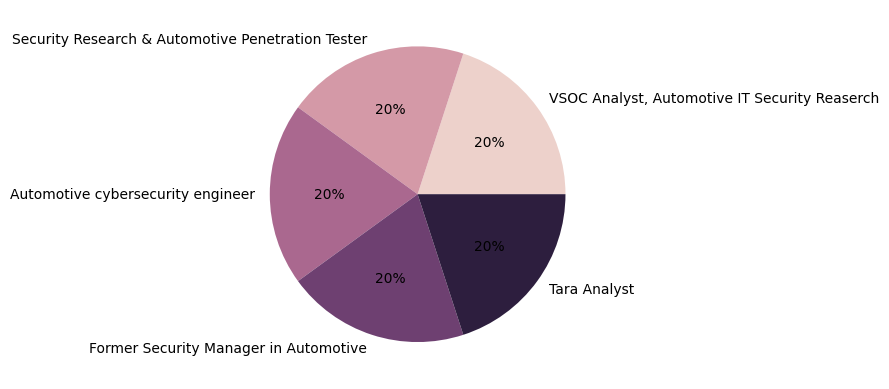

In [ ]:
colors = sns.cubehelix_palette(len(job))
mylabels = job.index.tolist()

plt.pie(job.values, labels = mylabels, colors = colors, autopct='%.0f%%')
plt.savefig("vehiclelogsources_roles.pdf",bbox_inches='tight')
plt.show()

### Survey Participant Experience

In [ ]:
exp = dataset["P002"].value_counts()
exp

,count
P002,
3,3
2,2


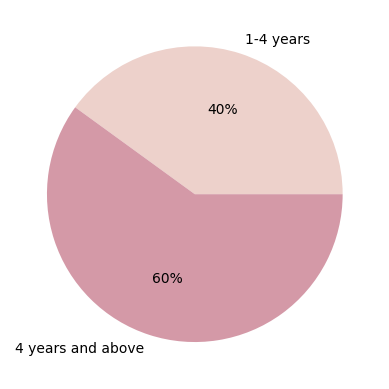

In [ ]:
y = np.array([0, 2, 3])
mylabels = ["<1 year", "1-4 years", "4 years and above"]

# Keep only non-zero values in the graph
mask = y>0

y_filtered = y[mask]
labels_filtered = np.array(mylabels)[mask]

plt.pie(y_filtered, labels = labels_filtered, colors = colors, autopct='%.0f%%')
plt.savefig("vehiclelogsources_experience.pdf",bbox_inches='tight')
plt.show()

## Vehicle Attack Surface Layers and their individual Components

### Vehicle Layer

In [ ]:
component_map = {
    "Q006": "Infotainment",
    "Q007": "Telematics",
    "Q008": "Central Unit",
    "Q009": "Communication Modules",
    "Q010": "Actuators",
    "Q011": "ECUs",
    "Q012": "OBD",
    "Q013": "Key",
    "Q014": "Bus Systems",
    "Q061": "Sensors",
    "Q015": "EDR",
    "Q016": "Comfort",
    "Q017": "Drive"
}

category_map = {
    "_01": "I agree with the component and its subcomponent(s)",
    "_02": "I agree with the colour of the component and its subcomponent(s)",
    "_03": "I disagree with the component or its subcomponent(s)",
    "_04": "I disagree with the colour of the component or its subcomponent(s)",
    "_05": "I have no opinion."
}


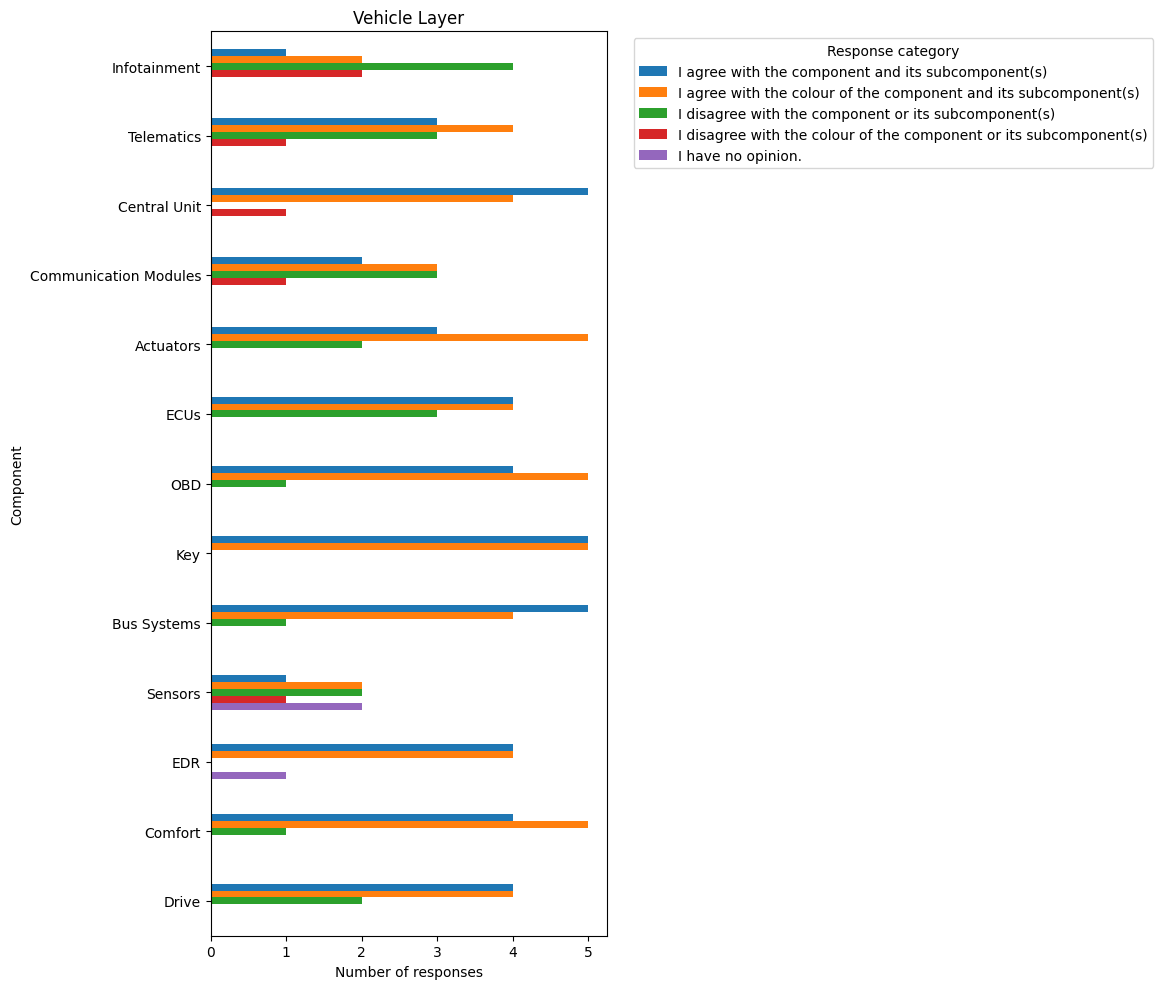

In [ ]:
rows = []

for question, component in component_map.items():
  for suffix, category in category_map.items():
    col = question + suffix

    if col in dataset.columns:
      """if col.startswith("Q006"):
        print(col)
        print(dataset[col].value_counts(dropna=False))"""
      rows.append({
        "Component": component,
        "Category": category,
        "Count": (dataset[col] == 2).sum()
      })

summary = pd.DataFrame(rows)

category_order = list(category_map.values())
component_order = list(component_map.values())

plot_data = summary.pivot(
    index="Component",
    columns="Category",
    values="Count"
).fillna(0)

# Keep original component order
plot_data = plot_data.reindex(component_order)

# Keep original category order
plot_data = plot_data[category_order]

color_map = {
    category_order[0]: "tab:blue",
    category_order[1]: "tab:orange",
    category_order[2]: "tab:green",
    category_order[3]: "tab:red",
    category_order[4]: "tab:purple"
}

colors_for_column = [color_map[col] for col in plot_data.columns]

ax = plot_data.plot(kind="barh", figsize=(12, 10), color=colors_for_column)

ax.invert_yaxis()

"""handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[::-1],
    labels[::-1],
    title="Response Category",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)"""

plt.xlabel("Number of responses")
plt.ylabel("Component")
plt.title("Vehicle Layer")
plt.legend(title="Response category", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.savefig("Vehicle_Layer.pdf", bbox_inches="tight")
plt.show()

### Missing Vehicle Layer Components

In [ ]:
missing_comps = [f"Q021_{i:02d}" for i in range(1,19)]
table_rows = []

for col in missing_comps:
  if col in dataset.columns:
    for value in dataset[col].dropna():

      value = str(value).strip()

      if value:
        table_rows.append({
            "Question": col,
            "Entry": value
        })

missing_table = pd.DataFrame(table_rows)

print(f"Number of missing components in this layer: {len(missing_table)}\n")
print(missing_table)

Number of missing components in this layer: 3

  Question                                    Entry
0  Q021_01                           WiFi/Bluetooth
1  Q021_02                                   E-Call
2  Q021_18  Vehicle Certificates (PKI) are missing.


### Proximity Layer

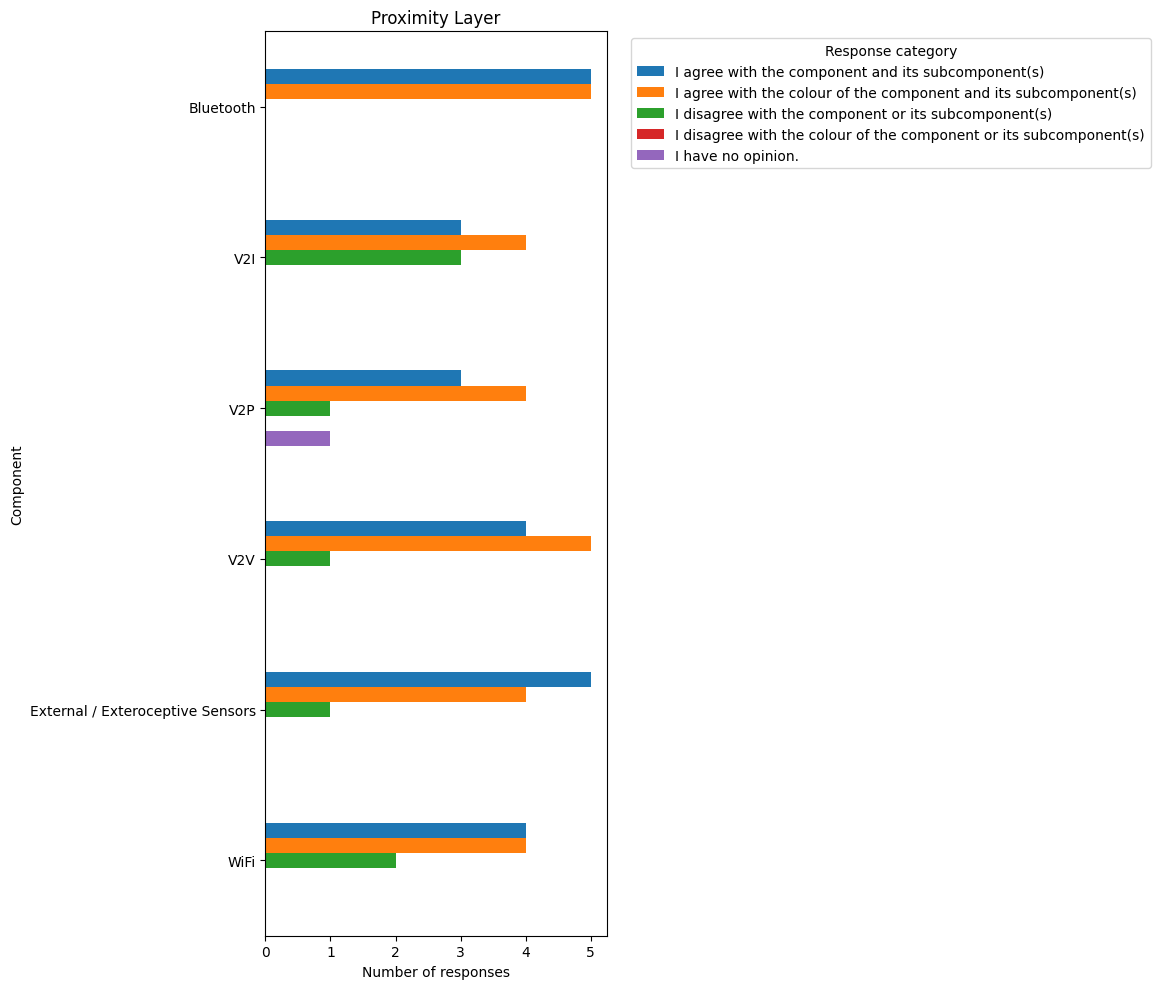

In [ ]:
component_map = {
    "Q023": "Bluetooth",
    "Q024": "V2I",
    "Q025": "V2P",
    "Q026": "V2V",
    "Q027": "External / Exteroceptive Sensors",
    "Q029": "WiFi"
}

category_map = {
    "_01": "I agree with the component and its subcomponent(s)",
    "_02": "I agree with the colour of the component and its subcomponent(s)",
    "_03": "I disagree with the component or its subcomponent(s)",
    "_04": "I disagree with the colour of the component or its subcomponent(s)",
    "_05": "I have no opinion."
}

rows = []

for question, component in component_map.items():
  for suffix, category in category_map.items():
    col = question + suffix

    if col in dataset.columns:
      """if col.startswith("Q006"):
        print(col)
        print(dataset[col].value_counts(dropna=False))"""
      rows.append({
        "Component": component,
        "Category": category,
        "Count": (dataset[col] == 2).sum()
      })

summary = pd.DataFrame(rows)

category_order = list(category_map.values())
component_order = list(component_map.values())

plot_data = summary.pivot(
    index="Component",
    columns="Category",
    values="Count"
).fillna(0)

# Keep original component order
plot_data = plot_data.reindex(component_order)

# Keep original category order
plot_data = plot_data[category_order]

color_map = {
    category_order[0]: "tab:blue",
    category_order[1]: "tab:orange",
    category_order[2]: "tab:green",
    category_order[3]: "tab:red",
    category_order[4]: "tab:purple"
}

colors_for_column = [color_map[col] for col in plot_data.columns]

ax = plot_data.plot(kind="barh", figsize=(12, 10), color=colors_for_column)

ax.invert_yaxis()

"""handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[::-1],
    labels[::-1],
    title="Response Category",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)"""

plt.xlabel("Number of responses")
plt.ylabel("Component")
plt.title("Proximity Layer")
plt.legend(title="Response category", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.savefig("Proximity_Layer.pdf", bbox_inches="tight")
plt.show()

### Missing Proximity Layer Components

In [ ]:
missing_comps = [f"Q031_{i:02d}" for i in range(1,11)]
table_rows = []

for col in missing_comps:
  if col in dataset.columns:
    for value in dataset[col].dropna():

      value = str(value).strip()

      if value:
        table_rows.append({
            "Question": col,
            "Entry": value
        })

# export the table to csv or excel
#missing_table.to_csv("missing_components.csv", index=False)
missing_table = pd.DataFrame(table_rows)

print(f"Number of missing components in this layer: {len(missing_table)}\n")
print(missing_table)

Number of missing components in this layer: 1

  Question                                              Entry
0  Q031_10  Fierewall from the previous taxonomy might be ...


### Backend & Cloud Layer

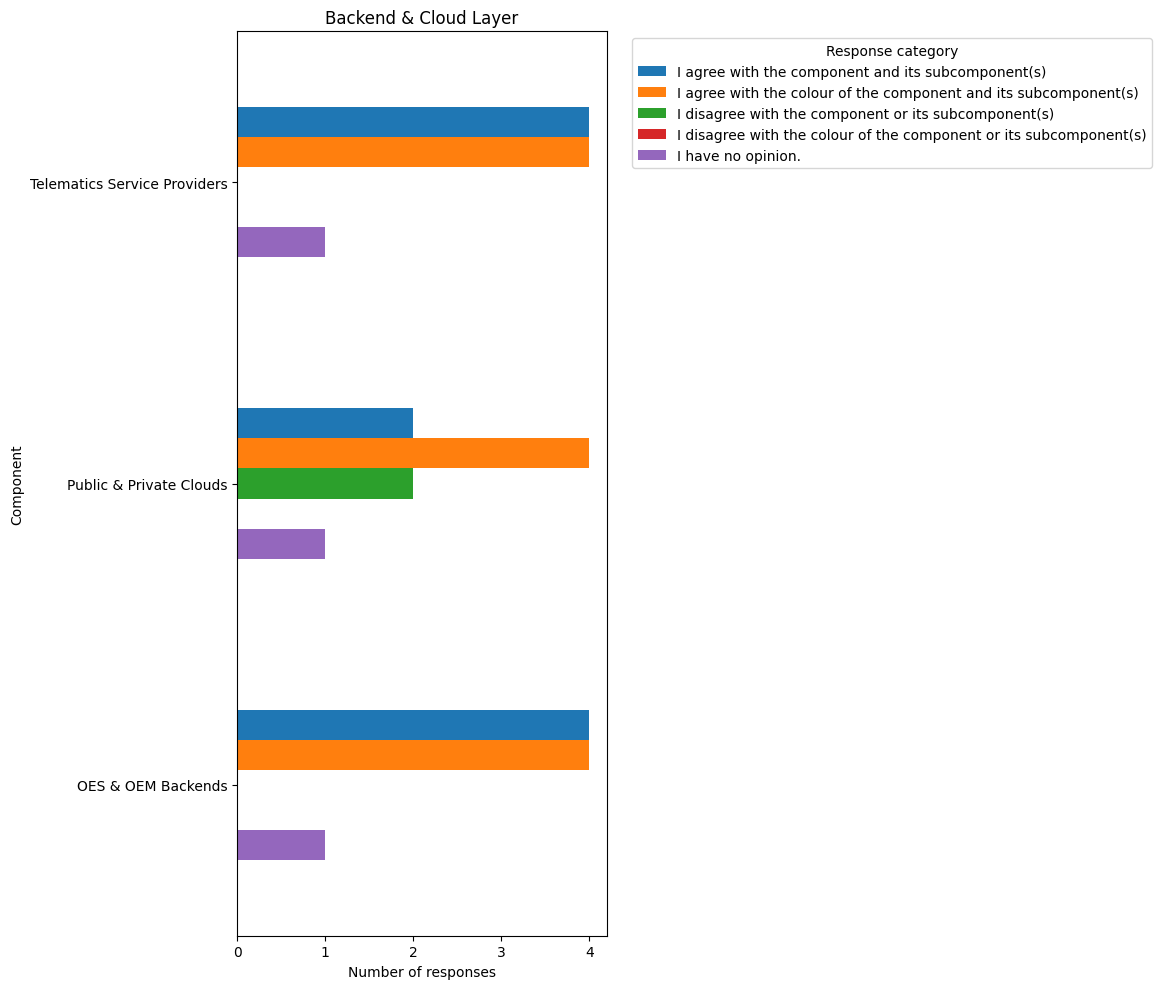

In [ ]:
component_map = {
    "Q033": "Telematics Service Providers",
    "Q034": "Public & Private Clouds",
    "Q038": "OES & OEM Backends"
}

category_map = {
    "_01": "I agree with the component and its subcomponent(s)",
    "_02": "I agree with the colour of the component and its subcomponent(s)",
    "_03": "I disagree with the component or its subcomponent(s)",
    "_04": "I disagree with the colour of the component or its subcomponent(s)",
    "_05": "I have no opinion."
}

rows = []

for question, component in component_map.items():
  for suffix, category in category_map.items():
    col = question + suffix

    if col in dataset.columns:
      """if col.startswith("Q006"):
        print(col)
        print(dataset[col].value_counts(dropna=False))"""
      rows.append({
        "Component": component,
        "Category": category,
        "Count": (dataset[col] == 2).sum()
      })

summary = pd.DataFrame(rows)

category_order = list(category_map.values())
component_order = list(component_map.values())

plot_data = summary.pivot(
    index="Component",
    columns="Category",
    values="Count"
).fillna(0)

# Keep original component order
plot_data = plot_data.reindex(component_order)

# Keep original category order
plot_data = plot_data[category_order]

color_map = {
    category_order[0]: "tab:blue",
    category_order[1]: "tab:orange",
    category_order[2]: "tab:green",
    category_order[3]: "tab:red",
    category_order[4]: "tab:purple"
}

colors_for_column = [color_map[col] for col in plot_data.columns]

ax = plot_data.plot(kind="barh", figsize=(12, 10), color=colors_for_column)

ax.invert_yaxis()

"""handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[::-1],
    labels[::-1],
    title="Response Category",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)"""

plt.xlabel("Number of responses")
plt.ylabel("Component")
plt.title("Backend & Cloud Layer")
plt.legend(title="Response category", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.savefig("BackendCloud_Layer.pdf", bbox_inches="tight")
plt.show()

### Missing Backend & Cloud Layer Components

In [ ]:
missing_comps = [f"Q040_{i:02d}" for i in range(1,9)]
table_rows = []

for col in missing_comps:
  if col in dataset.columns:
    for value in dataset[col].dropna():

      value = str(value).strip()

      if value:
        table_rows.append({
            "Question": col,
            "Entry": value
        })

missing_table = pd.DataFrame(table_rows)

print(f"Number of missing components in this layer: {len(missing_table)}\n")
print(missing_table)

Number of missing components in this layer: 0

Empty DataFrame
Columns: []
Index: []


### Network Layer

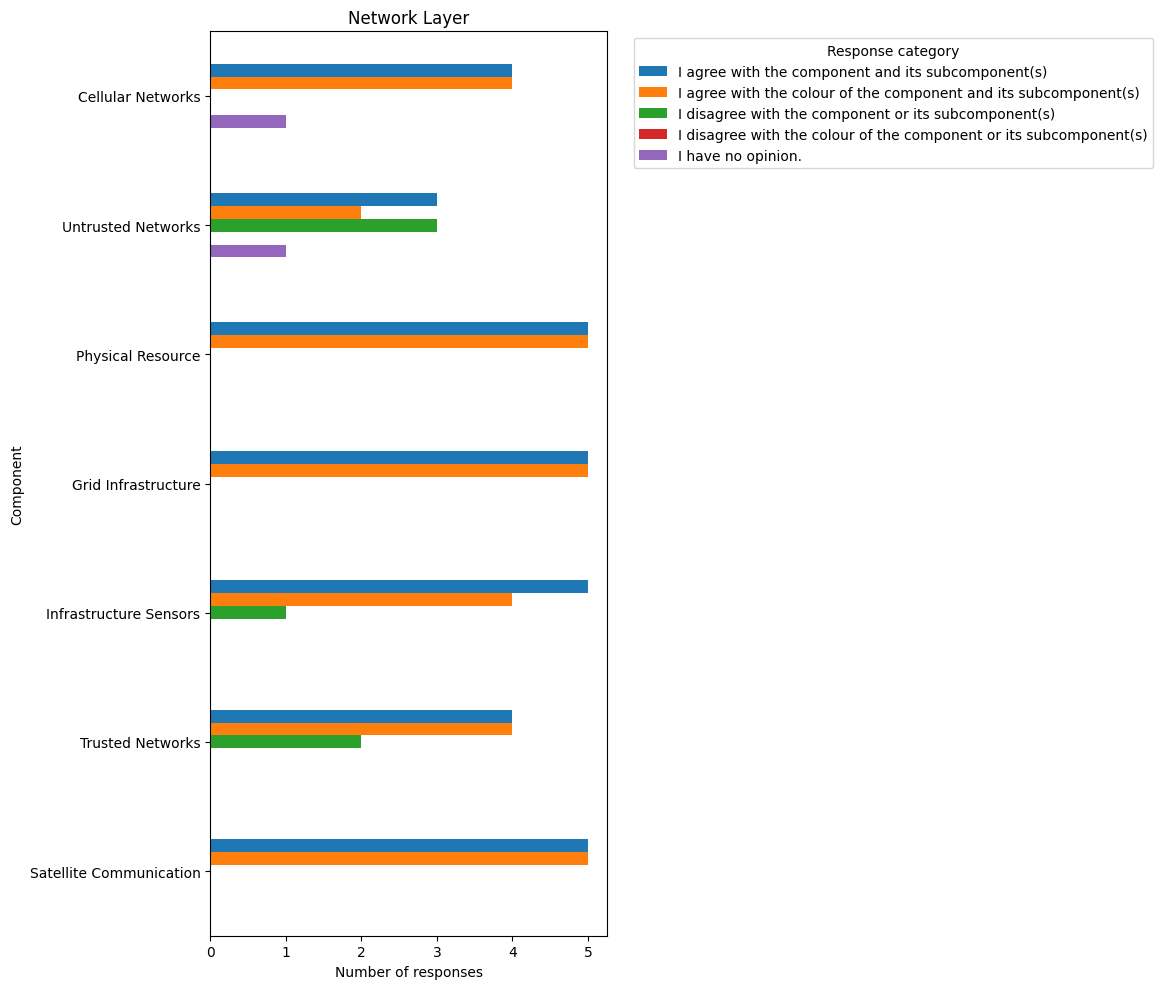

In [ ]:
component_map = {
    "Q042": "Cellular Networks",
    "Q043": "Untrusted Networks",
    "Q044": "Physical Resource",
    "Q045": "Grid Infrastructure",
    "Q046": "Infrastructure Sensors",
    "Q047": "Trusted Networks",
    "Q048": "Satellite Communication"
}

category_map = {
    "_01": "I agree with the component and its subcomponent(s)",
    "_02": "I agree with the colour of the component and its subcomponent(s)",
    "_03": "I disagree with the component or its subcomponent(s)",
    "_04": "I disagree with the colour of the component or its subcomponent(s)",
    "_05": "I have no opinion."
}

rows = []

for question, component in component_map.items():
  for suffix, category in category_map.items():
    col = question + suffix

    if col in dataset.columns:
      """if col.startswith("Q006"):
        print(col)
        print(dataset[col].value_counts(dropna=False))"""
      rows.append({
        "Component": component,
        "Category": category,
        "Count": (dataset[col] == 2).sum()
      })

summary = pd.DataFrame(rows)

category_order = list(category_map.values())
component_order = list(component_map.values())

plot_data = summary.pivot(
    index="Component",
    columns="Category",
    values="Count"
).fillna(0)

# Keep original component order
plot_data = plot_data.reindex(component_order)

# Keep original category order
plot_data = plot_data[category_order]

color_map = {
    category_order[0]: "tab:blue",
    category_order[1]: "tab:orange",
    category_order[2]: "tab:green",
    category_order[3]: "tab:red",
    category_order[4]: "tab:purple"
}

colors_for_column = [color_map[col] for col in plot_data.columns]

ax = plot_data.plot(kind="barh", figsize=(12, 10), color=colors_for_column)

ax.invert_yaxis()

"""handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[::-1],
    labels[::-1],
    title="Response Category",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)"""

plt.xlabel("Number of responses")
plt.ylabel("Component")
plt.title("Network Layer")
plt.legend(title="Response category", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.savefig("Network_Layer.pdf", bbox_inches="tight")
plt.show()

### Missing Network Layer Components

In [ ]:
missing_comps = [f"Q052_{i:02d}" for i in range(1,13)]
table_rows = []

for col in missing_comps:
  if col in dataset.columns:
    for value in dataset[col].dropna():

      value = str(value).strip()

      if value:
        table_rows.append({
            "Question": col,
            "Entry": value
        })

missing_table = pd.DataFrame(table_rows)

print(f"Number of missing components in this layer: {len(missing_table)}\n")
print(missing_table)

Number of missing components in this layer: 0

Empty DataFrame
Columns: []
Index: []


## Missing Layers

In [ ]:
layers_missing = dataset["Q055_01"]
print(f"Number of missing layers: {len(layers_missing)}\n")
layers_missing

KeyError: 'Q055_01'

In [ ]:
missing_layers = [f"Q055_{i:02d}" for i in range(1,13)]
table_rows = []

for col in missing_layers:
  if col in dataset.columns:
    for value in dataset[col].dropna():

      value = str(value).strip()

      if value:
        table_rows.append({
            "Question": col,
            "Entry": value
        })

missing_table = pd.DataFrame(table_rows)

print(missing_table)

## Feedback

In [ ]:
feedback = dataset["Q056_01"]
print(print(f"Number of feedbacks: {len(feedback)}\n"))
feedback

In [ ]:
feedback = dataset["Q056_01"].dropna()

for i, response in enumerate(feedback, start=1):
  response = str(response).strip()

  if response:
    print(f"\nFeedback {i}:")
    print(response)

In [ ]:
feedback_table = pd.DataFrame({
    "Feedback": dataset["Q056_01"]
})

feedback_table = feedback_table.dropna()

feedback_table = feedback_table[
    feedback_table["Feedback"].astype(str).str.strip() != ""
]

feedback_table = feedback_table.reset_index(drop=True)

feedback_table.insert(
    0, "No.", range(1, len(feedback_table)+1)
)

display(feedback_table.style.set_properties(**{'text-align': 'left'}))

#feedback_table.to_excel("Feedback.xlsx", index=False)

## Comments

In [ ]:
rows = []

for col in dataset.columns:

    match = re.match(r"^Q(\d{3})_\d{2}a$", col)

    if match:

        question_number = int(match.group(1))

        if 1 <= question_number <= 70:

            responses = dataset[col].dropna()

            for response in responses:

                response = str(response).strip()

                if response:
                    rows.append({
                        "Question": col,
                        "Comment": response
                    })
comment_table = pd.DataFrame(rows)

comment_table.insert(
    0,
    "No.",
    range(1, len(comment_table) + 1)
)

comment_table
#comment_table.to_excel("disagreement_reasonings.xlsx", index=False)

In [ ]:
import zipfile
from google.colab import files

chart_files = [
    "vehiclelogsources_age.pdf",
    "vehiclelogsources_roles.pdf",
    "vehiclelogsources_experience.pdf",
    "Vehicle_Layer.pdf",
    "Proximity_Layer.pdf",
    "BackendCloud_Layer.pdf",
    "Network_Layer.pdf"
]

with zipfile.ZipFile("charts_and_tables.zip", "w") as zipf:
  for file in chart_files:
    zipf.write(file)

files.download("charts_and_tables.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>